# 04 - Hyperparameter Optimization

## Optimización de hiperparámetros

Este notebook corresponde a la etapa de optimización de modelos supervisados.

El objetivo es mejorar el rendimiento ajustando hiperparámetros utilizando:

- GridSearchCV
- RandomizedSearchCV

La optimización permite encontrar configuraciones más adecuadas para cada algoritmo y mejorar capacidad de generalización.


In [21]:
# Librerías principales.
import pandas as pd
import numpy as np

# Librerías de visualización.
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de Machine Learning.
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Modelos.
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Métricas.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Configuración visual.
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


## 1. Carga del dataset

Se utiliza el mismo dataset del proyecto de abandono de clientes.


In [53]:
def cargar_datos(url):
    """ Función que recibe la url del archivo a leer """
    df = pd.read_csv(url)
    print("Dataset cargado correctamente")
    print(df.head(5))
    return df

In [46]:
url = "https://raw.githubusercontent.com/magomezn-debug/dScience_001D/main/data/datos_clientes_limpios.csv"

# para cargar datos
df = cargar_datos(url)

Dataset cargado correctamente
   edad  ingreso_mensual  gasto_mensual   deuda_total  score_crediticio  \
0  66.0     9.243057e+05  524088.303055  2.448145e+06        455.406680   
1  51.0     1.384687e+06  314259.751474  1.620569e+06        575.048508   
2  48.0     8.047533e+05  387192.316142  5.395040e+06        770.716904   
3  54.0     4.369032e+05  417328.601856  2.999350e+06        442.722671   
4  31.0     7.408561e+05  490961.191253  1.637711e+06        468.188403   

   antiguedad_meses  frecuencia_compra  ultima_compra_dias  num_productos  \
0             101.0                6.0               356.0            3.0   
1              65.0                8.0               307.0            4.0   
2               1.0               12.0               232.0            4.0   
3               4.0                3.0               165.0            2.0   
4              14.0                5.0               283.0            3.0   

   genero_Masculino  ...  tipo_plan_Premium  canal_regis

In [47]:
# Carga del dataset.


# Separación de variables.
X = df.drop('abandono', axis=1)
y = df['abandono']

# División train/test.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Dataset cargado correctamente.')
print('Tamaño entrenamiento:', X_train.shape)
print('Tamaño prueba:', X_test.shape)

Dataset cargado correctamente.
Tamaño entrenamiento: (16000, 27)
Tamaño prueba: (4000, 27)


## 2. Identificación de variables

Las variables numéricas y categóricas requieren tratamientos distintos dentro del pipeline.


In [48]:
# Identificación automática de columnas numéricas.
columnas_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Identificación automática de columnas categóricas.
columnas_categoricas = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print('Columnas numéricas:')
print(columnas_numericas)

print('\nColumnas categóricas:')
print(columnas_categoricas)

Columnas numéricas:
['edad', 'ingreso_mensual', 'gasto_mensual', 'deuda_total', 'score_crediticio', 'antiguedad_meses', 'frecuencia_compra', 'ultima_compra_dias', 'num_productos', 'genero_Masculino', 'genero_Otro', 'region_Norte', 'region_Sur', 'estado_civil_Divorciado', 'estado_civil_Soltero', 'uso_app_Bajo', 'uso_app_Medio', 'tipo_plan_Estandar', 'tipo_plan_Premium', 'canal_registro_Tienda', 'canal_registro_Web', 'dia_semana_registro_Jueves', 'dia_semana_registro_Lunes', 'dia_semana_registro_Martes', 'dia_semana_registro_Miercoles', 'dia_semana_registro_Sabado', 'dia_semana_registro_Viernes']

Columnas categóricas:
[]


## 3. Construcción del preprocessing

Se construyen pipelines para:
- imputación,
- escalamiento,
- codificación categórica.

Esto permite evitar data leakage y mantener reproducibilidad.


In [49]:
# Pipeline numérico.
pipeline_numerico = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline categórico.
pipeline_categorico = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# ColumnTransformer.
preprocessor = ColumnTransformer([
    ('num', pipeline_numerico, columnas_numericas),
    ('cat', pipeline_categorico, columnas_categoricas)
])

print('Preprocessing creado correctamente.')

Preprocessing creado correctamente.


# 4. Optimización de Logistic Regression con GridSearchCV

GridSearchCV prueba exhaustivamente múltiples combinaciones de hiperparámetros.

En Logistic Regression el parámetro más importante es:

- C: controla regularización.


In [50]:
# Pipeline completo para Logistic Regression.
pipeline_logistic = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# Grid de hiperparámetros.
param_grid_logistic = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2']
}

# GridSearchCV.
grid_logistic = GridSearchCV(
    pipeline_logistic,
    param_grid=param_grid_logistic,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Entrenamiento.
grid_logistic.fit(X_train, y_train)

print('Mejores parámetros Logistic Regression:')
print(grid_logistic.best_params_)

print('\nMejor F1-score:')
print(round(grid_logistic.best_score_, 4))

Mejores parámetros Logistic Regression:
{'model__C': 1, 'model__penalty': 'l2'}

Mejor F1-score:
0.4562


In [51]:
# =========================
# Logistic Regression
# =========================

pipeline_logistic = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_logistic = {
    'model__C': [0.1, 1, 10]
}

grid_logistic = GridSearchCV(
    pipeline_logistic,
    param_grid=param_grid_logistic,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_logistic.fit(X_train, y_train)

print('Mejores parámetros Logistic Regression:')
print(grid_logistic.best_params_)

print('\nMejor F1-score Logistic Regression:')
print(round(grid_logistic.best_score_, 4))

Mejores parámetros Logistic Regression:
{'model__C': 1}

Mejor F1-score Logistic Regression:
0.455


# 5. Optimización de Decision Tree con GridSearchCV

Decision Tree es muy sensible al overfitting.

Por eso se optimizan hiperparámetros relacionados con:
- profundidad,
- tamaño mínimo de nodos,
- división de muestras.


In [52]:
# Pipeline Decision Tree.
pipeline_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

# Grid de hiperparámetros.
param_grid_tree = {
    'model__max_depth': [3, 5, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2, 4]
}

# GridSearchCV.
grid_tree = GridSearchCV(
    pipeline_tree,
    param_grid=param_grid_tree,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

# Entrenamiento.
grid_tree.fit(X_train, y_train)

print('Mejores parámetros Decision Tree:')
print(grid_tree.best_params_)

print('\nMejor F1-score:')
print(round(grid_tree.best_score_, 4))

Mejores parámetros Decision Tree:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}

Mejor F1-score:
0.4517


In [34]:
# =========================
# Decision Tree
# =========================

pipeline_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

param_grid_tree = {
    'model__max_depth': [3, 5, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

grid_tree = GridSearchCV(
    pipeline_tree,
    param_grid=param_grid_tree,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_tree.fit(X_train, y_train)

print('Mejores parámetros Decision Tree:')
print(grid_tree.best_params_)

print('\nMejor F1-score Decision Tree:')
print(round(grid_tree.best_score_, 4))

Mejores parámetros Decision Tree:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}

Mejor F1-score Decision Tree:
0.45166


# 6. Optimización de SVM con GridSearchCV

SVM depende fuertemente de:
- C,
- kernel

Estos parámetros controlan:
- margen,
- complejidad,
- capacidad de adaptación.


In [30]:
# Pipeline SVM.
pipeline_svm = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(probability=True, random_state=42))
])

# Grid de hiperparámetros.
param_grid_svm = {
    'model__C': [0.1, 1],
    'model__kernel': ['linear']
}

# GridSearchCV.
grid_svm = GridSearchCV(
    pipeline_svm,
    param_grid=param_grid_svm,
    cv=2,    scoring='f1',
    n_jobs=-1
)

# Entrenamiento.
grid_svm.fit(X_train, y_train)

print('Mejores parámetros SVM:')
print(grid_svm.best_params_)

print('\nMejor F1-score:')
print(round(grid_svm.best_score_, 4))

Mejores parámetros SVM:
{'model__C': 0.1, 'model__kernel': 'linear'}

Mejor F1-score:
0.4805


In [36]:
# =========================
# SVM
# =========================

pipeline_svm = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(probability=True, random_state=42))
])

param_grid_svm = {
    'model__C': [0.1, 1],
    'model__kernel': ['linear']
}

grid_svm = GridSearchCV(
    pipeline_svm,
    param_grid=param_grid_svm,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print('Mejores parámetros SVM:')
print(grid_svm.best_params_)

print('\nMejor F1-score SVM:')
print(round(grid_svm.best_score_, 4))

Mejores parámetros SVM:
{'model__C': 0.1, 'model__kernel': 'linear'}

Mejor F1-score SVM:
0.4806


# 7. Optimización de KNN con RandomizedSearchCV

KNN depende principalmente de:
- cantidad de vecinos,
- distancia utilizada,
- peso de vecinos.

RandomizedSearchCV permite explorar configuraciones de forma más eficiente.


In [31]:
# Pipeline KNN.
pipeline_knn = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

# Distribución de hiperparámetros.
param_dist_knn = {
    'model__n_neighbors': [5, 7],
    'model__weights': ['uniform'],
    'model__metric': ['euclidean']
}

# RandomizedSearchCV.
random_knn = RandomizedSearchCV(
    pipeline_knn,
    param_distributions=param_dist_knn,
    n_iter=2,
    cv=2,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

# Entrenamiento.
random_knn.fit(X_train, y_train)

print('Mejores parámetros KNN:')
print(random_knn.best_params_)

print('\nMejor F1-score:')
print(round(random_knn.best_score_, 4))

Mejores parámetros KNN:
{'model__weights': 'uniform', 'model__n_neighbors': 5, 'model__metric': 'euclidean'}

Mejor F1-score:
0.4156


In [37]:
# =========================
# KNN
# =========================

pipeline_knn = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

param_dist_knn = {
    'model__n_neighbors': [3, 5, 7],
    'model__weights': ['uniform'],
    'model__metric': ['euclidean']
}

random_knn = RandomizedSearchCV(
    pipeline_knn,
    param_distributions=param_dist_knn,
    n_iter=3,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

random_knn.fit(X_train, y_train)

print('Mejores parámetros KNN:')
print(random_knn.best_params_)

print('\nMejor F1-score KNN:')
print(round(random_knn.best_score_, 4))

Mejores parámetros KNN:
{'model__weights': 'uniform', 'model__n_neighbors': 3, 'model__metric': 'euclidean'}

Mejor F1-score KNN:
0.4223


# 8. Comparación de modelos optimizados

Se comparan los modelos después de optimización utilizando F1-score.

Esto permite observar el impacto de los hiperparámetros sobre el rendimiento.


In [38]:
# Tabla comparativa final de modelos optimizados.
resultados_optim = pd.DataFrame({
    'Modelo': [
        'Logistic Regression',
        'Decision Tree',
        'SVM',
        'KNN'
    ],
    'Mejores hiperparámetros': [
        grid_logistic.best_params_,
        grid_tree.best_params_,
        grid_svm.best_params_,
        random_knn.best_params_
    ],
    'Mejor F1-score': [
        grid_logistic.best_score_,
        grid_tree.best_score_,
        grid_svm.best_score_,
        random_knn.best_score_
    ]
})

# Ordenar de mejor a peor según F1-score.
resultados_optim = resultados_optim.sort_values(
    by='Mejor F1-score',
    ascending=False
)

# Redondear el F1-score para que se vea más limpio.
resultados_optim['Mejor F1-score'] = resultados_optim['Mejor F1-score'].round(4)

# Mostrar tabla final.
resultados_optim

,Modelo,Mejores hiperparámetros,Mejor F1-score
2,SVM,"{'model__C': 0.1, 'model__kernel': 'linear'}",0.4806
0,Logistic Regression,{'model__C': 1},0.4550
1,Decision Tree,"{'model__max_depth': None, 'model__min_samples...",0.4517
3,KNN,"{'model__weights': 'uniform', 'model__n_neighb...",0.4223


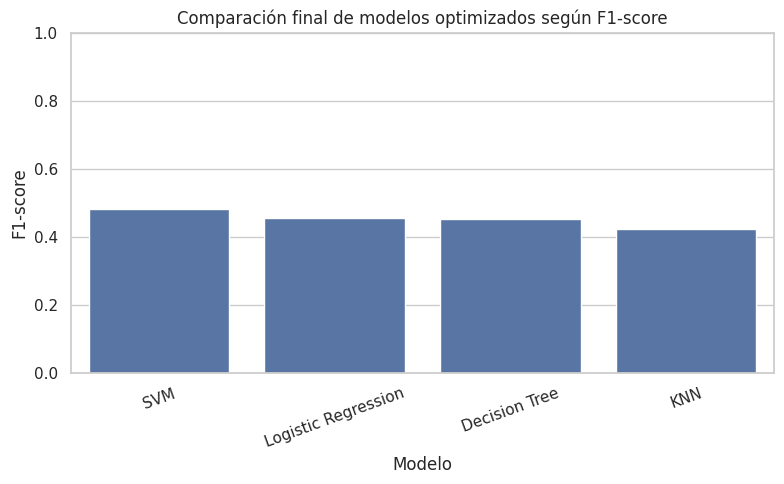

In [39]:
#Grafico final

plt.figure(figsize=(8, 5))

sns.barplot(
    data=resultados_optim,
    x='Modelo',
    y='Mejor F1-score'
)

plt.title('Comparación final de modelos optimizados según F1-score')
plt.xlabel('Modelo')
plt.ylabel('F1-score')
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

# 9. Impacto de la optimización

La optimización de hiperparámetros permitió mejorar el rendimiento ajustando configuraciones específicas de cada modelo.

Los hiperparámetros afectan:
- complejidad,
- capacidad de generalización,
- riesgo de overfitting,
- sensibilidad a patrones.

Por ejemplo:
- en SVM, valores incorrectos de C pueden provocar sobreajuste,
- en Decision Tree, profundidades muy grandes generan árboles demasiado específicos,
- en KNN, una cantidad incorrecta de vecinos puede provocar underfitting u overfitting.

Por esta razón, la optimización es una etapa crítica dentro de Machine Learning.


# 10. Conclusión

La optimización permitió comparar distintas configuraciones y observar cómo pequeños cambios en hiperparámetros impactan significativamente el rendimiento final.

Esta etapa demuestra que en Machine Learning no basta solamente con entrenar modelos básicos. También es necesario ajustar cuidadosamente los parámetros para construir sistemas más robustos, estables y capaces de generalizar correctamente frente a datos nuevos.
